## Loading EIA Electricity Data

This section imports the needed Python libraries, loads my EIA API key, and defines the base API URL for the EIA retail electricity sales dataset. I use this dataset because it includes annual electricity sales, prices, revenue, and customer counts by state and sector.

In [1]:
import os, requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from dotenv import load_dotenv

load_dotenv()
API_KEY = os.getenv("EIA_API_KEY")
BASE_URL = "https://api.eia.gov/v2/electricity/retail-sales/data/"

def get_eia(state="VA", sector="COM", metric="sales", start="2010", end="2024"):
    params = {
        "api_key": API_KEY,
        "frequency": "annual",
        "data[]": metric,
        "facets[stateid][]": state,
        "facets[sectorid][]": sector,
        "start": start,
        "end": end,
        "sort[0][column]": "period",
        "sort[0][direction]": "asc",
        "length": 5000
    }
    r = requests.get(BASE_URL, params=params)
    r.raise_for_status()
    df = pd.DataFrame(r.json()["response"]["data"])
    df["period"] = pd.to_numeric(df["period"])
    df[metric] = pd.to_numeric(df[metric])
    return df

def clean_axes(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(alpha=0.25)

## Function for Pulling EIA Data

The `get_eia` function sends a request to the EIA API for a specific state, sector, metric, and time range. It returns the API response as a cleaned pandas DataFrame.

The function also converts the `period` column into numeric years and converts the selected metric, such as `sales` or `price`, into numeric values so the data can be plotted and analyzed.

## Cleaning Plot Appearance

The `clean_axes` function removes the top and right borders from the plot and adds a light grid. This makes the graph easier to read and gives it a cleaner appearance.


In [2]:
states = ["VA", "MD", "NC", "PA", "US"]
sectors = ["RES", "COM", "IND", "ALL"]
metrics = ["sales", "price", "revenue", "customers"]

frames = []

for_state = []
for state in states:
    for sector in sectors:
        metric_frames = []
        for metric in metrics:
            temp = get_eia(state, sector, metric)
            temp = temp[["period", "stateid", "stateDescription", "sectorid", "sectorName", metric]]
            metric_frames.append(temp)

        merged = metric_frames[0]
        for mdf in metric_frames[1:]:
            merged = merged.merge(
                mdf,
                on=["period", "stateid", "stateDescription", "sectorid", "sectorName"],
                how="outer"
            )
        frames.append(merged)

retail = pd.concat(frames, ignore_index=True)
retail.head()

,period,stateid,stateDescription,sectorid,sectorName,sales,price,revenue,customers
0,2010,VA,Virginia,RES,residential,48438.95800,10.45,5061.60340,NaN
1,2011,VA,Virginia,RES,residential,45771.14400,10.64,4871.34880,NaN
2,2012,VA,Virginia,RES,residential,43534.67500,11.08,4822.89280,NaN
3,2013,VA,Virginia,RES,residential,45416.25301,10.84,4924.51001,NaN
4,2014,VA,Virginia,RES,residential,46443.71600,11.10,5155.28080,NaN


## Collecting Data Across States, Sectors, and Metrics

This section loops through multiple states, electricity sectors, and metrics. For each state-sector pair, it pulls annual data for sales, price, revenue, and customers from the EIA API.

Each metric is first retrieved separately, then merged into one DataFrame using the year, state, and sector columns. Finally, all of the state-sector DataFrames are combined into one larger dataset called `retail`.

## Filtering to Virginia

Here, I filter the full dataset so that only Virginia observations remain. Since my paper focuses on Virginia and data center electricity demand, this lets me make a sector-level graph specifically for Virginia.

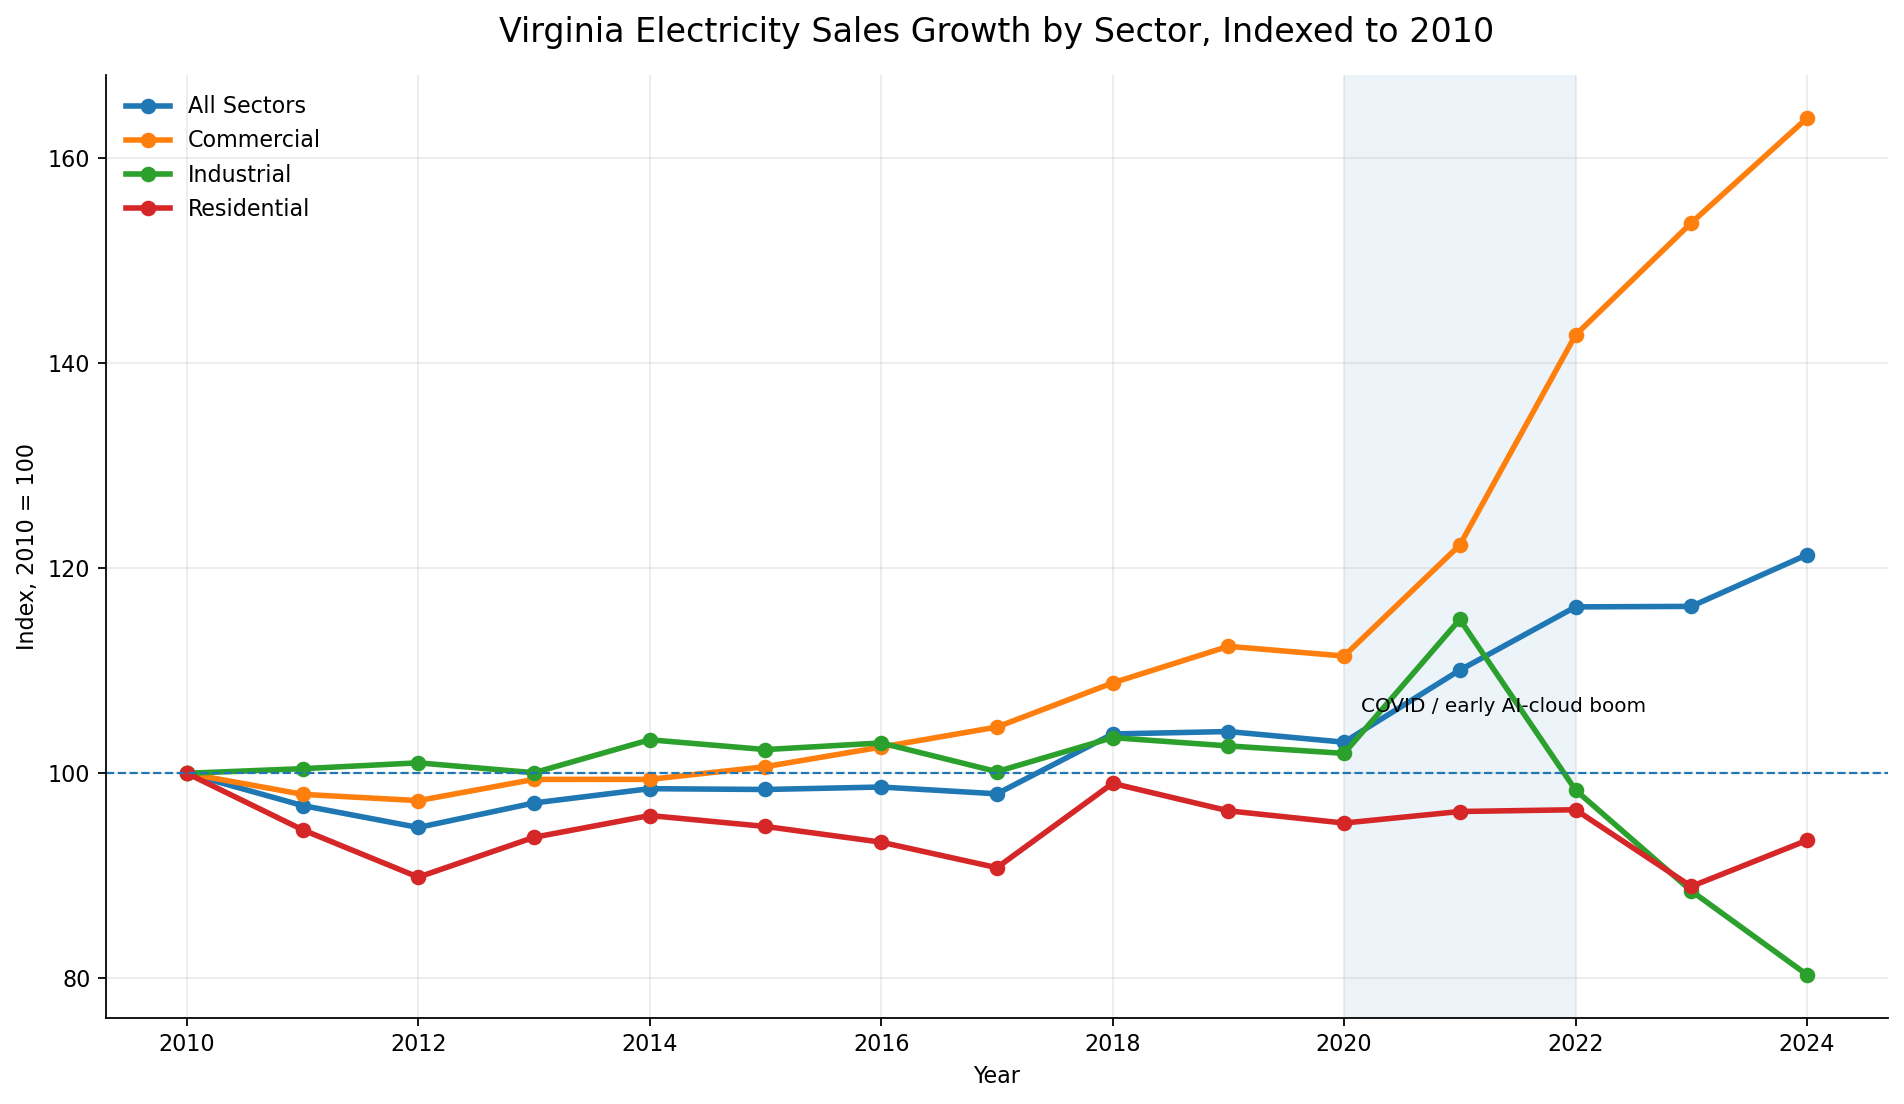

In [4]:
va = retail[retail["stateid"] == "VA"].copy()

fig, ax = plt.subplots(figsize=(12, 7), dpi=160)

for sector, group in va.groupby("sectorName"):
    group = group.sort_values("period")
    group["sales_index"] = group["sales"] / group["sales"].iloc[0] * 100
    ax.plot(group["period"], group["sales_index"], marker="o", linewidth=2.5, label=sector.title())

ax.axhline(100, linestyle="--", linewidth=1)
ax.axvspan(2020, 2022, alpha=0.08)
ax.text(2020.15, 106, "COVID / early AI-cloud boom", fontsize=9)

ax.set_title("Virginia Electricity Sales Growth by Sector, Indexed to 2010", fontsize=15, pad=15)
ax.set_xlabel("Year")
ax.set_ylabel("Index, 2010 = 100")
clean_axes(ax)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

## Plotting Indexed Electricity Sales Growth

This graph shows how electricity sales changed in Virginia from 2010 to 2024 across different sectors. Instead of plotting raw electricity sales, each sector is indexed to its own 2010 value.

This means every sector starts at 100 in 2010, making it easier to compare relative growth across sectors. The commercial sector is especially important because data centers are usually included in commercial electricity categories.

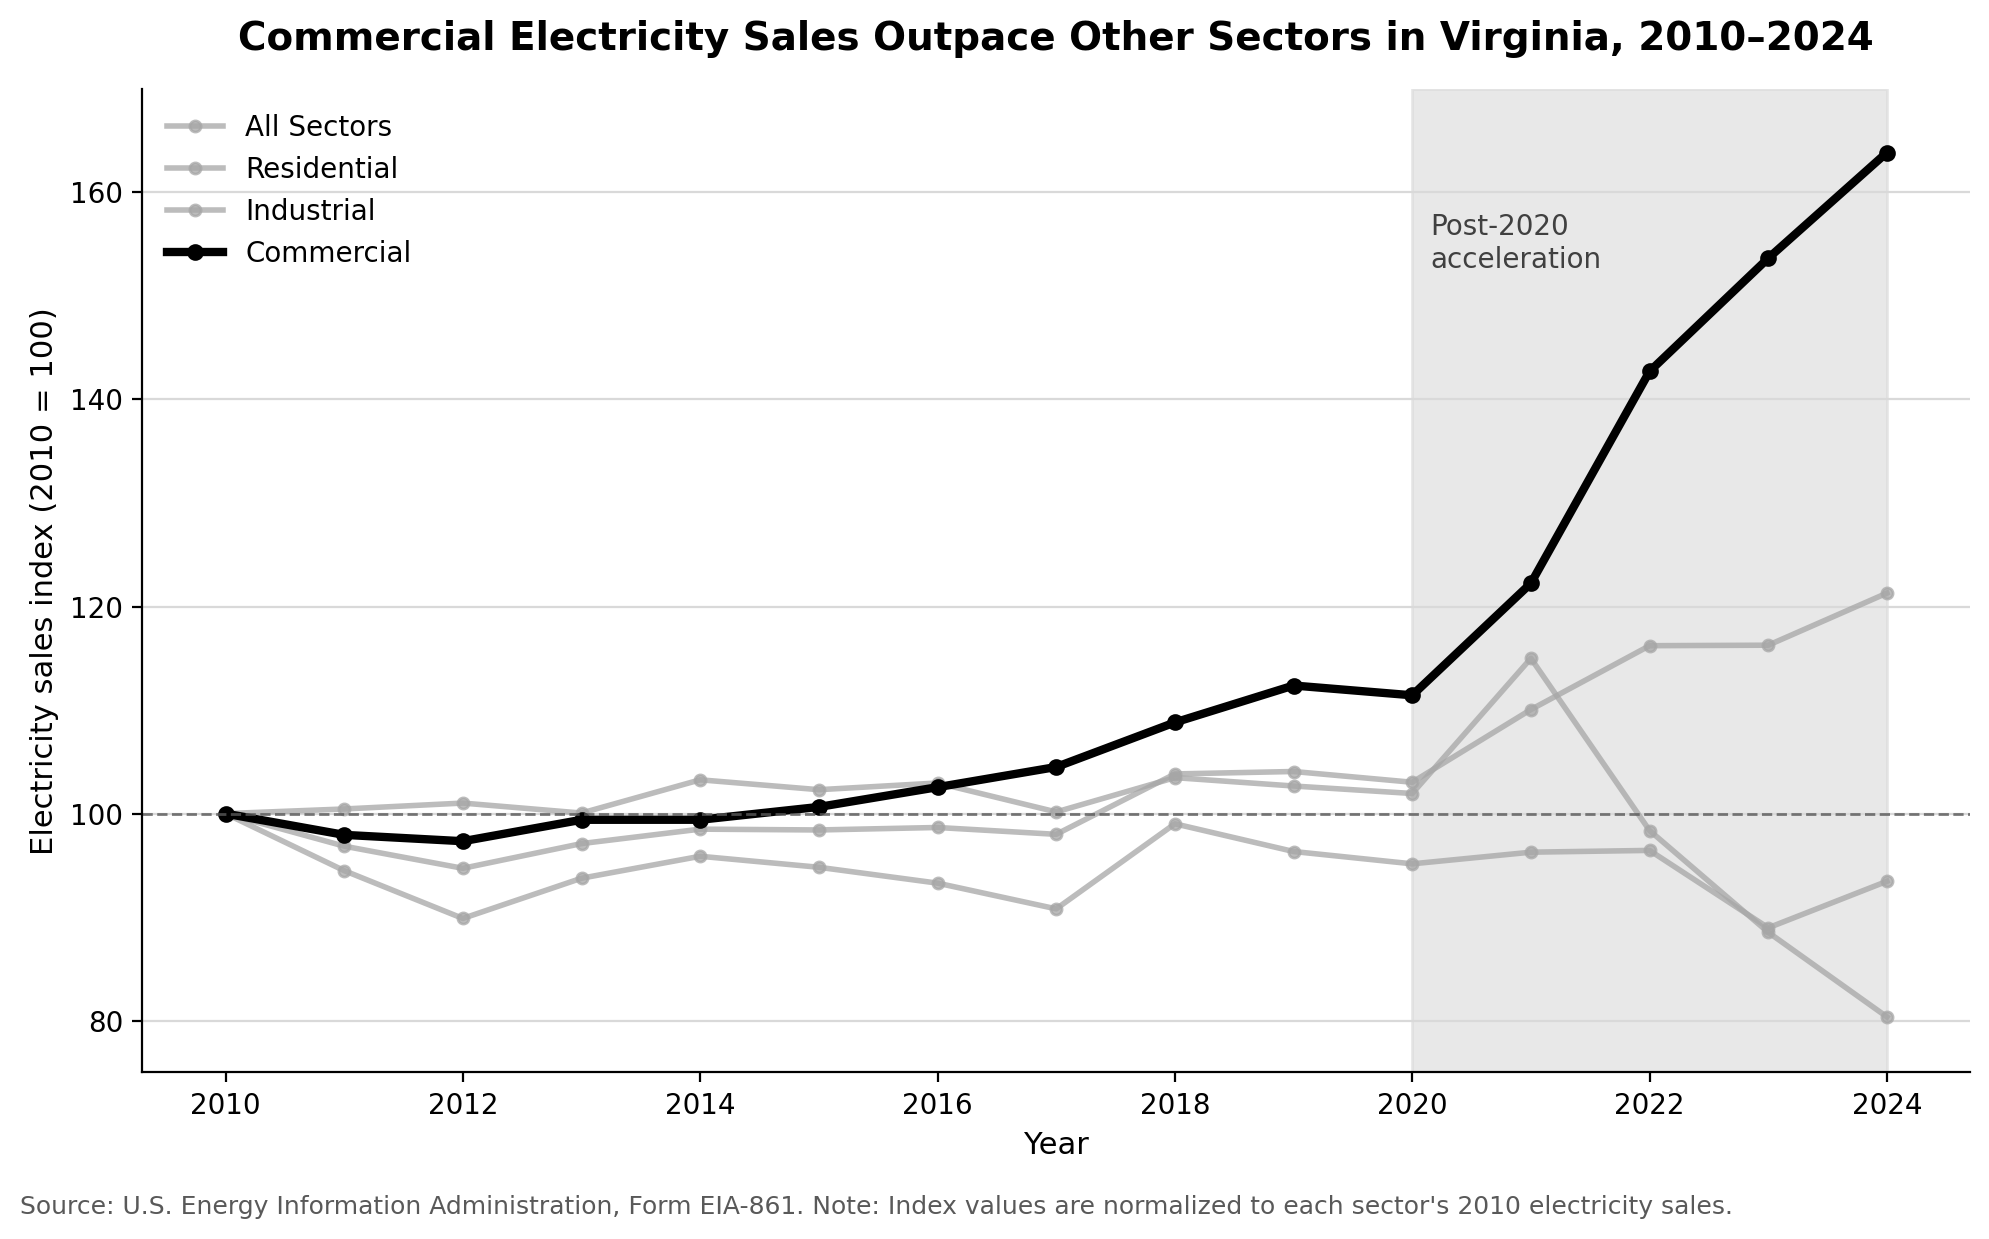

In [15]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

va = retail[retail["stateid"] == "VA"].copy()

# Keep only the sectors you want in the final figure
sector_order = ["commercial", "residential", "industrial", "all sectors"]
va = va[va["sectorName"].isin(sector_order)]

fig, ax = plt.subplots(figsize=(10, 6), dpi=200)

# Plot muted comparison lines first
muted_sectors = ["all sectors", "residential", "industrial"]

for sector in muted_sectors:
    group = va[va["sectorName"] == sector].sort_values("period").copy()
    group["sales_index"] = group["sales"] / group["sales"].iloc[0] * 100

    ax.plot(
        group["period"],
        group["sales_index"],
        linewidth=2,
        marker="o",
        markersize=4,
        color="0.65",
        alpha=0.75,
        label=sector.title()
    )

# Highlight commercial sector
commercial = va[va["sectorName"] == "commercial"].sort_values("period").copy()
commercial["sales_index"] = commercial["sales"] / commercial["sales"].iloc[0] * 100

ax.plot(
    commercial["period"],
    commercial["sales_index"],
    linewidth=3,
    marker="o",
    markersize=5,
    color="black",
    label="Commercial"
)

# Baseline
ax.axhline(100, linestyle="--", linewidth=1, color="0.35", alpha=0.8)

# Shaded post-2020 period
ax.axvspan(2020, 2024, color="0.85", alpha=0.6, zorder=0)
ax.text(
    2020.15,
    158,
    "Post-2020\nacceleration",
    fontsize=10,
    color="0.25",
    va="top"
)

# Titles and labels
ax.set_title(
    "Commercial Electricity Sales Outpace Other Sectors in Virginia, 2010–2024",
    fontsize=14,
    fontweight="bold",
    pad=14
)

ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("Electricity sales index (2010 = 100)", fontsize=11)

# Axis formatting
ax.set_ylim(75, 170)
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.tick_params(axis="both", labelsize=10)

# Cleaner grid and frame
ax.grid(axis="y", color="0.85", linewidth=0.8)
ax.grid(axis="x", visible=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Legend
ax.legend(frameon=False, loc="upper left", fontsize=10)

# Source note
fig.text(
    0.01,
    -0.02,
    "Source: U.S. Energy Information Administration, Form EIA-861. "
    "Note: Index values are normalized to each sector's 2010 electricity sales.",
    ha="left",
    fontsize=9,
    color="0.35"
)

plt.tight_layout()
plt.show()

## Highlighting Commercial Electricity Sales Growth in Virginia

This figure focuses on Virginia electricity sales from 2010 to 2024. I keep four sector categories: commercial, residential, industrial, and all sectors. The goal is to compare commercial electricity growth against the other major electricity-use categories.

The graph uses an index where each sector starts at 100 in 2010. This means the figure is showing relative growth, not total electricity use. For example, a value of 150 means that sector’s electricity sales are 50% higher than they were in 2010.

The commercial sector is highlighted in white because it is the most important category for this project. Data centers are generally included in commercial electricity demand, so highlighting this line helps show how commercial electricity use has grown compared to residential, industrial, and overall electricity sales.

The other sectors are shown in gray so they can still be compared, but they do not distract from the main commercial trend. The shaded area after 2020 marks the period where electricity demand growth appears to accelerate, which is relevant to the recent expansion of cloud computing, AI infrastructure, and data centers in Virginia.

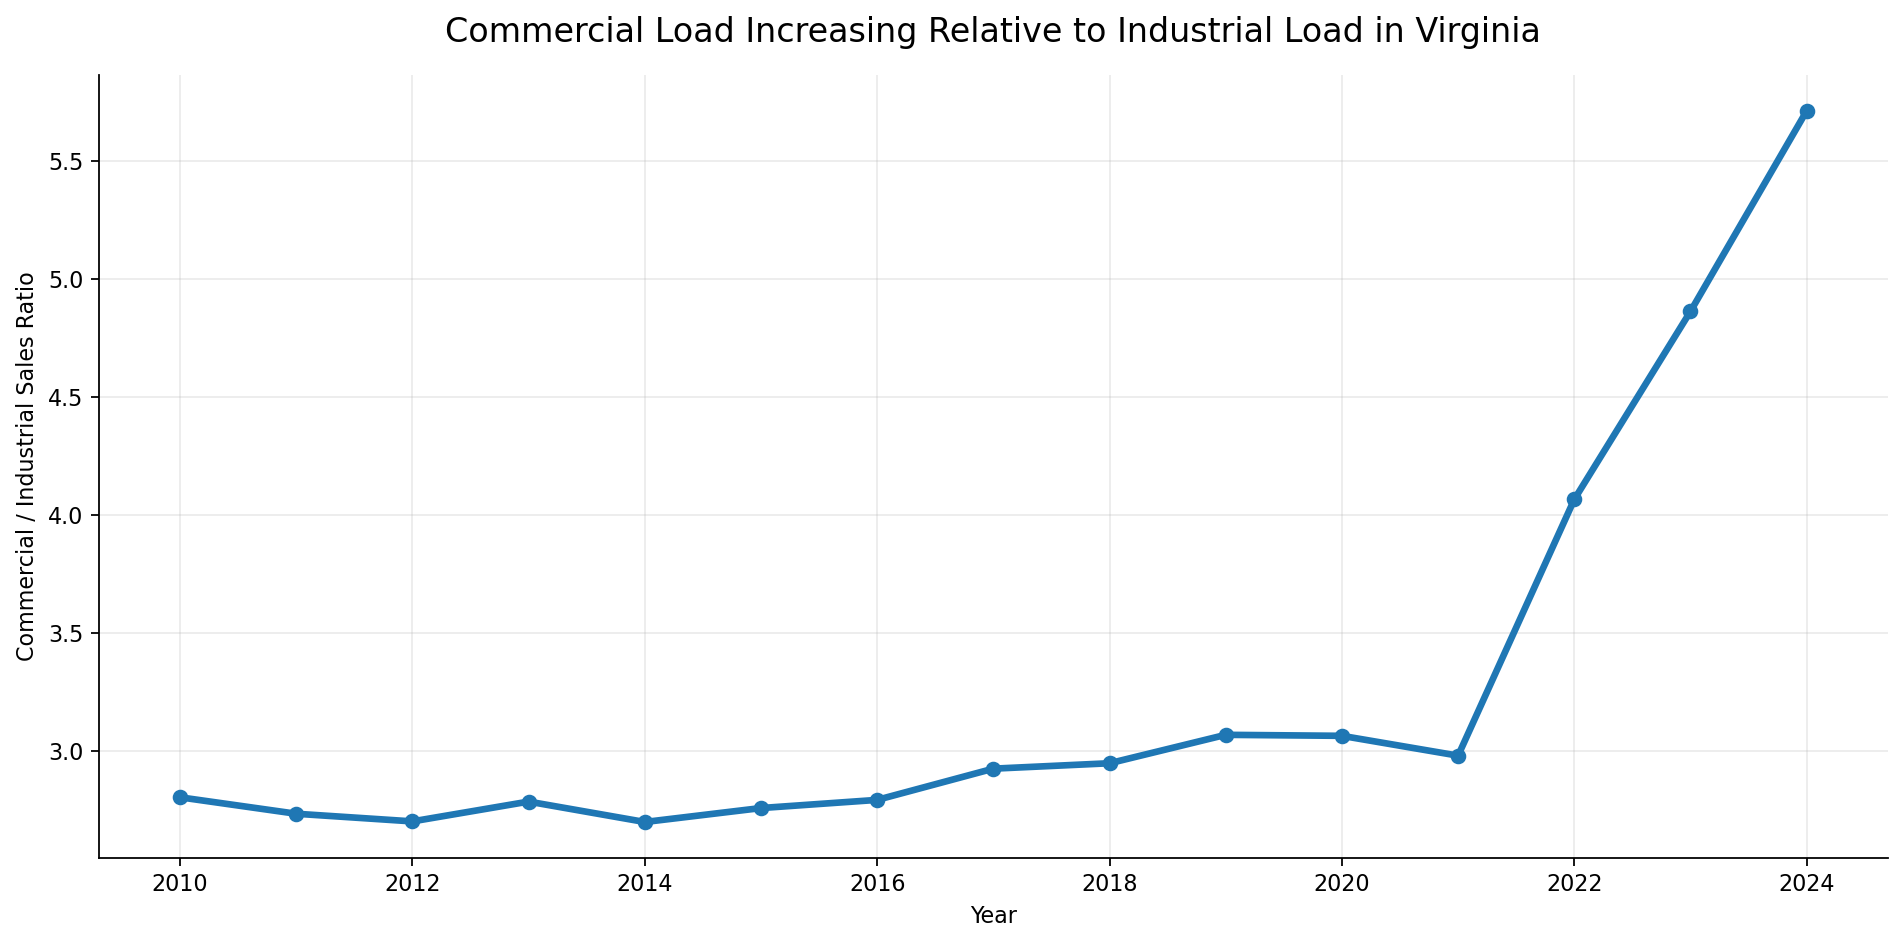

In [5]:
wide = va.pivot_table(
    index="period",
    columns="sectorid",
    values="sales",
    aggfunc="first"
).reset_index()

wide["commercial_minus_industrial"] = wide["COM"] - wide["IND"]
wide["commercial_to_industrial_ratio"] = wide["COM"] / wide["IND"]

fig, ax = plt.subplots(figsize=(12, 6), dpi=160)

ax.plot(wide["period"], wide["commercial_to_industrial_ratio"], marker="o", linewidth=3)

ax.set_title("Commercial Load Increasing Relative to Industrial Load in Virginia", fontsize=15, pad=15)
ax.set_xlabel("Year")
ax.set_ylabel("Commercial / Industrial Sales Ratio")
clean_axes(ax)

plt.tight_layout()
plt.show()

## Comparing Commercial and Industrial Electricity Load

This section reshapes the Virginia electricity data so that each sector becomes its own column. This makes it easier to directly compare commercial and industrial electricity load in the same year.

I then calculate two new values:

- `commercial_minus_industrial`: the difference between commercial and industrial electricity load.
- `commercial_to_industrial_ratio`: the ratio of commercial load to industrial load.

The ratio is useful because it shows how large commercial electricity demand is compared to industrial demand. A ratio above 1 means commercial load is higher than industrial load. A rising ratio means commercial electricity demand is increasing relative to industrial electricity demand.

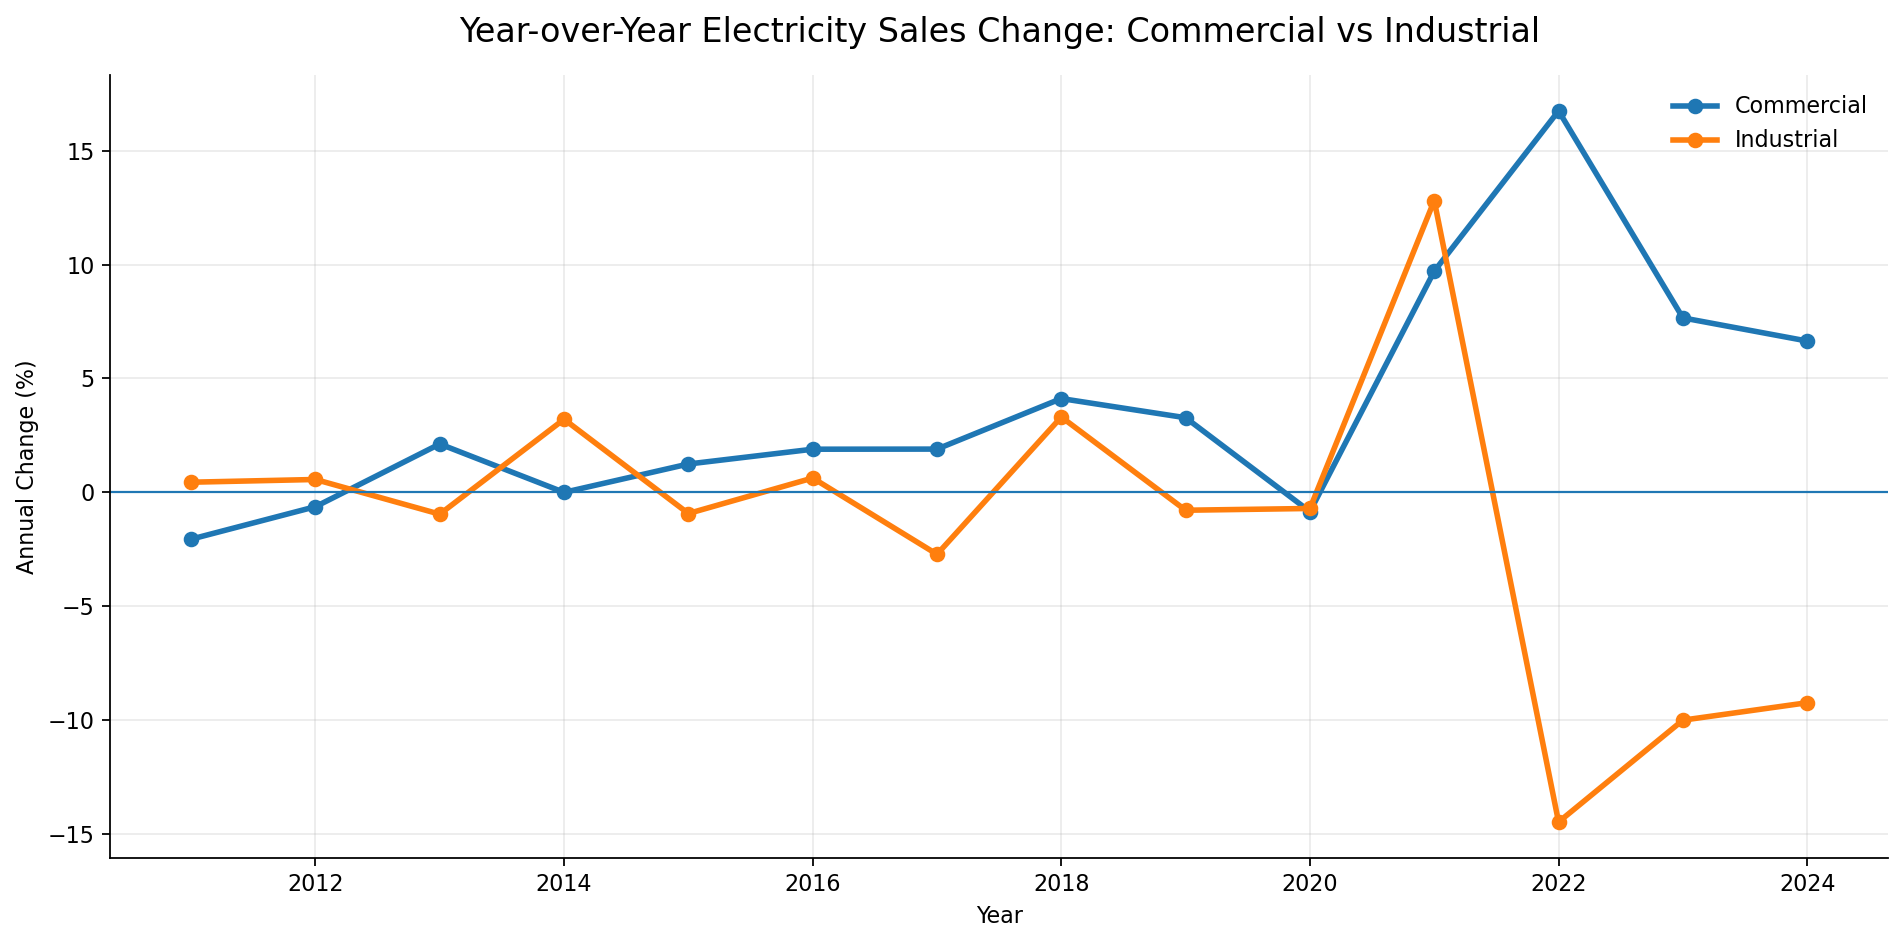

In [6]:
fig, ax = plt.subplots(figsize=(12, 6), dpi=160)

for sector in ["commercial", "industrial"]:
    group = va[va["sectorName"] == sector].sort_values("period").copy()
    group["yoy"] = group["sales"].pct_change() * 100
    ax.plot(group["period"], group["yoy"], marker="o", linewidth=2.5, label=sector.title())

ax.axhline(0, linewidth=1)
ax.set_title("Year-over-Year Electricity Sales Change: Commercial vs Industrial", fontsize=15, pad=15)
ax.set_xlabel("Year")
ax.set_ylabel("Annual Change (%)")
clean_axes(ax)
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

## Year-over-Year Sales Change

This graph compares the annual percent change in commercial and industrial electricity salesin Virginia. Instead of showing total growth over time, it shows how much each sector changed from one year to the next.

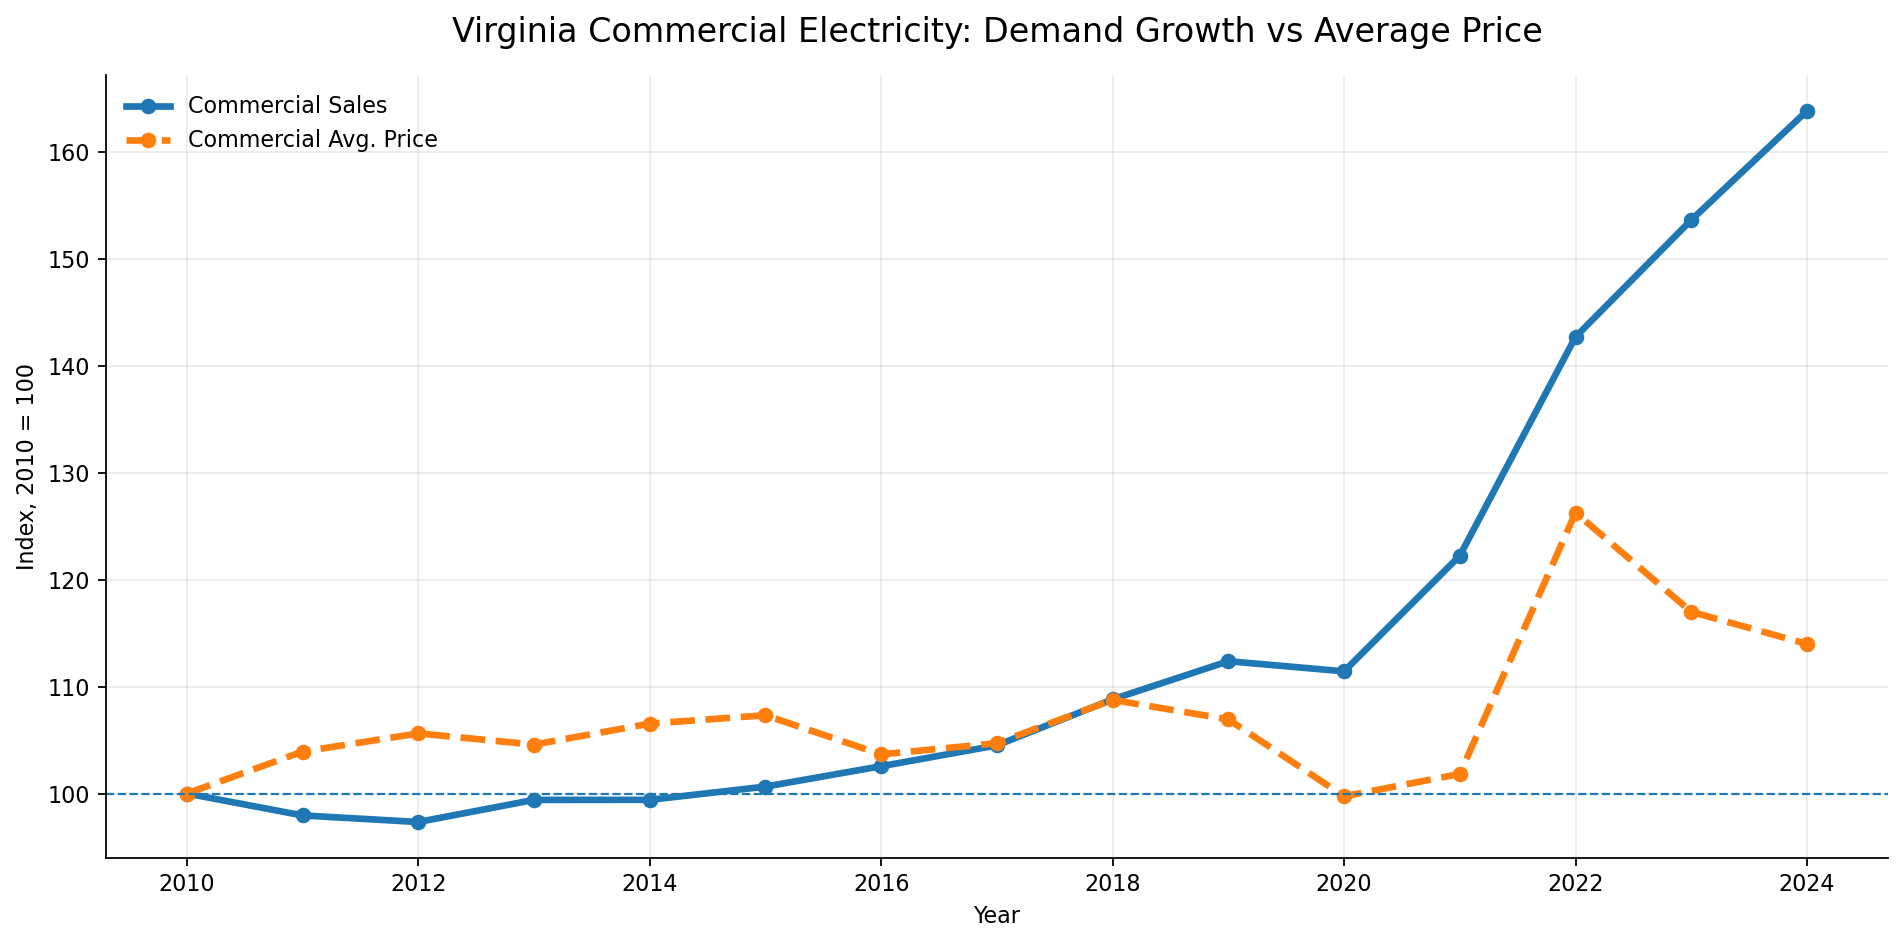

In [7]:
com = va[va["sectorid"] == "COM"].sort_values("period").copy()
com["sales_index"] = com["sales"] / com["sales"].iloc[0] * 100
com["price_index"] = com["price"] / com["price"].iloc[0] * 100

fig, ax = plt.subplots(figsize=(12, 6), dpi=160)

ax.plot(com["period"], com["sales_index"], marker="o", linewidth=3, label="Commercial Sales")
ax.plot(com["period"], com["price_index"], marker="o", linewidth=3, linestyle="--", label="Commercial Avg. Price")

ax.axhline(100, linestyle="--", linewidth=1)
ax.set_title("Virginia Commercial Electricity: Demand Growth vs Average Price", fontsize=15, pad=15)
ax.set_xlabel("Year")
ax.set_ylabel("Index, 2010 = 100")
clean_axes(ax)
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

## Commercial Electricity Sales vs Price

This graph compares Virginia’s commercial electricity sales and average commercial electricity price from 2010 to 2024. Both are indexed to 2010, so the graph shows relative change instead of raw values.

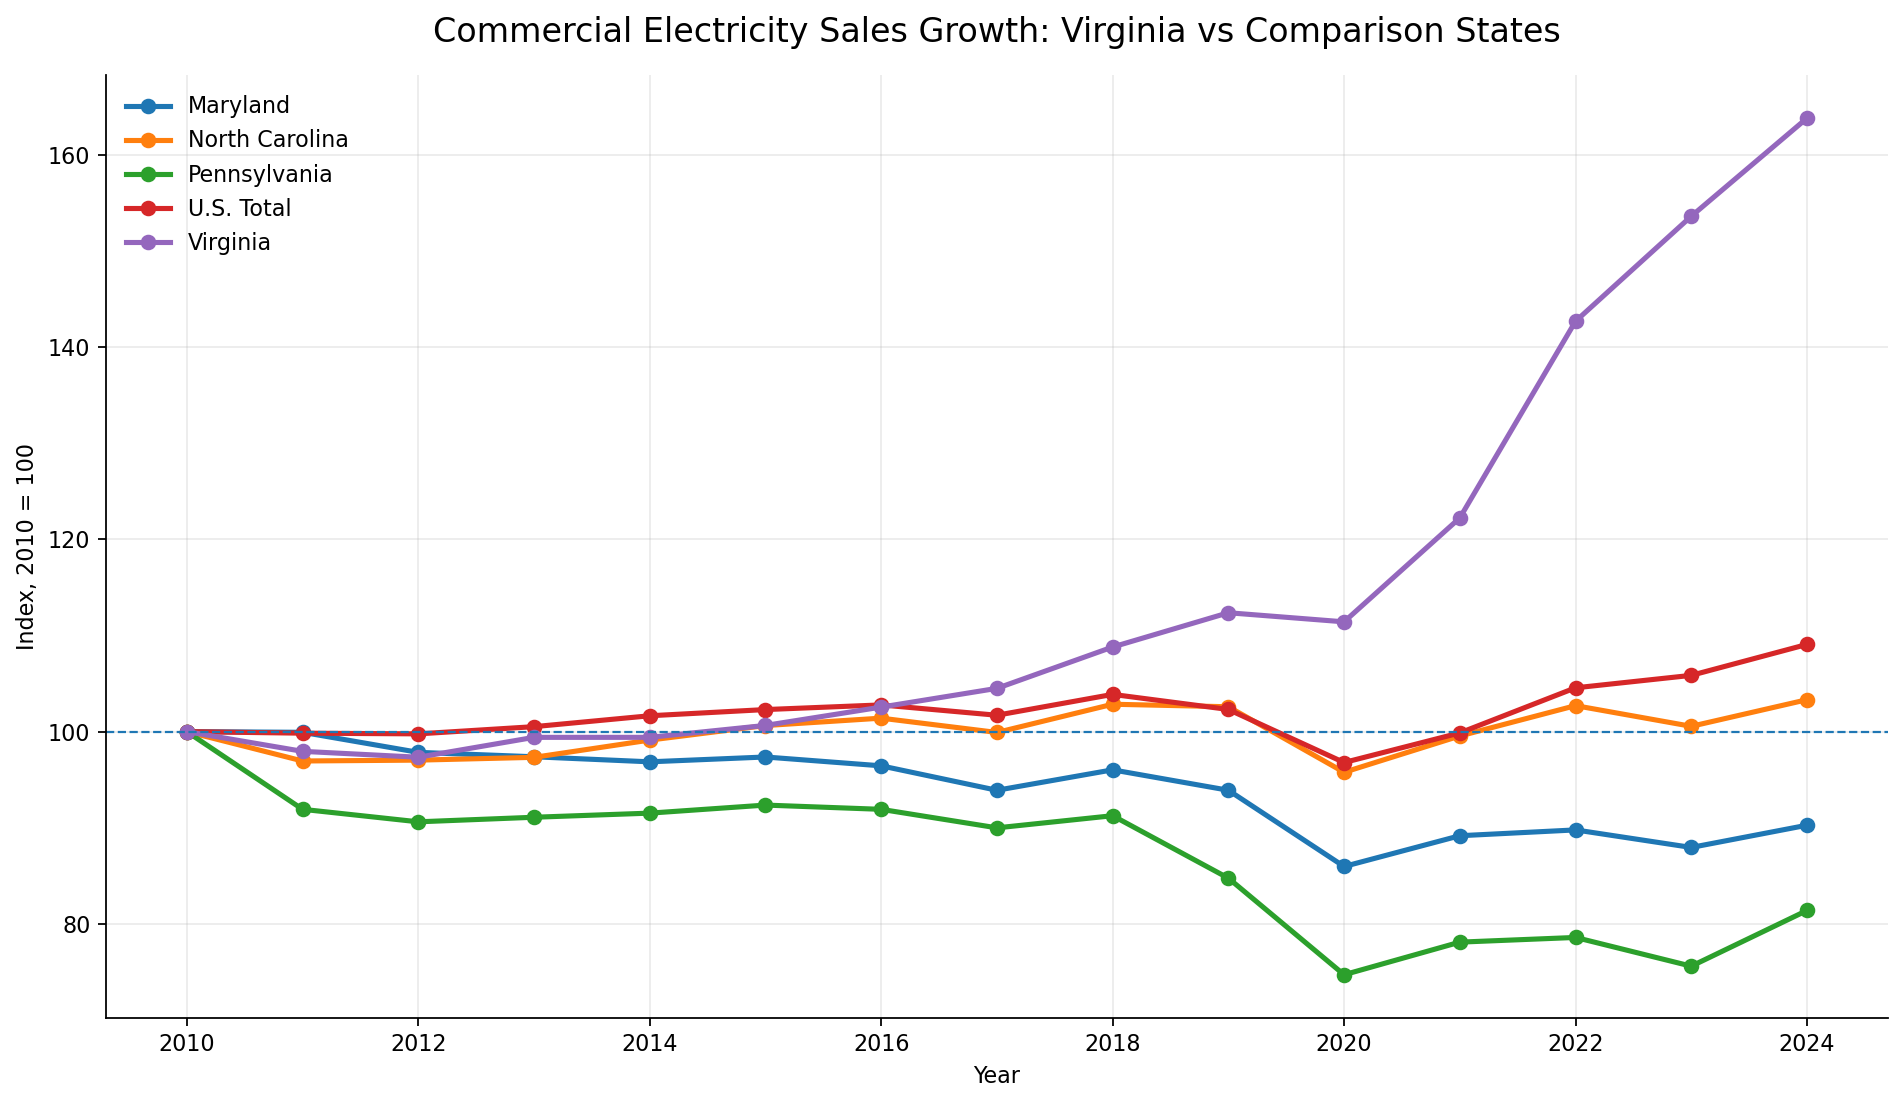

In [4]:
comp = retail[retail["sectorid"] == "COM"].copy()

fig, ax = plt.subplots(figsize=(12, 7), dpi=160)

for state, group in comp.groupby("stateDescription"):
    group = group.sort_values("period")
    group["sales_index"] = group["sales"] / group["sales"].iloc[0] * 100
    ax.plot(group["period"], group["sales_index"], marker="o", linewidth=2.3, label=state)

ax.axhline(100, linestyle="--", linewidth=1)
ax.set_title("Commercial Electricity Sales Growth: Virginia vs Comparison States", fontsize=15, pad=15)
ax.set_xlabel("Year")
ax.set_ylabel("Index, 2010 = 100")
clean_axes(ax)
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

In [6]:
va = retail[retail["stateid"] == "VA"].copy()

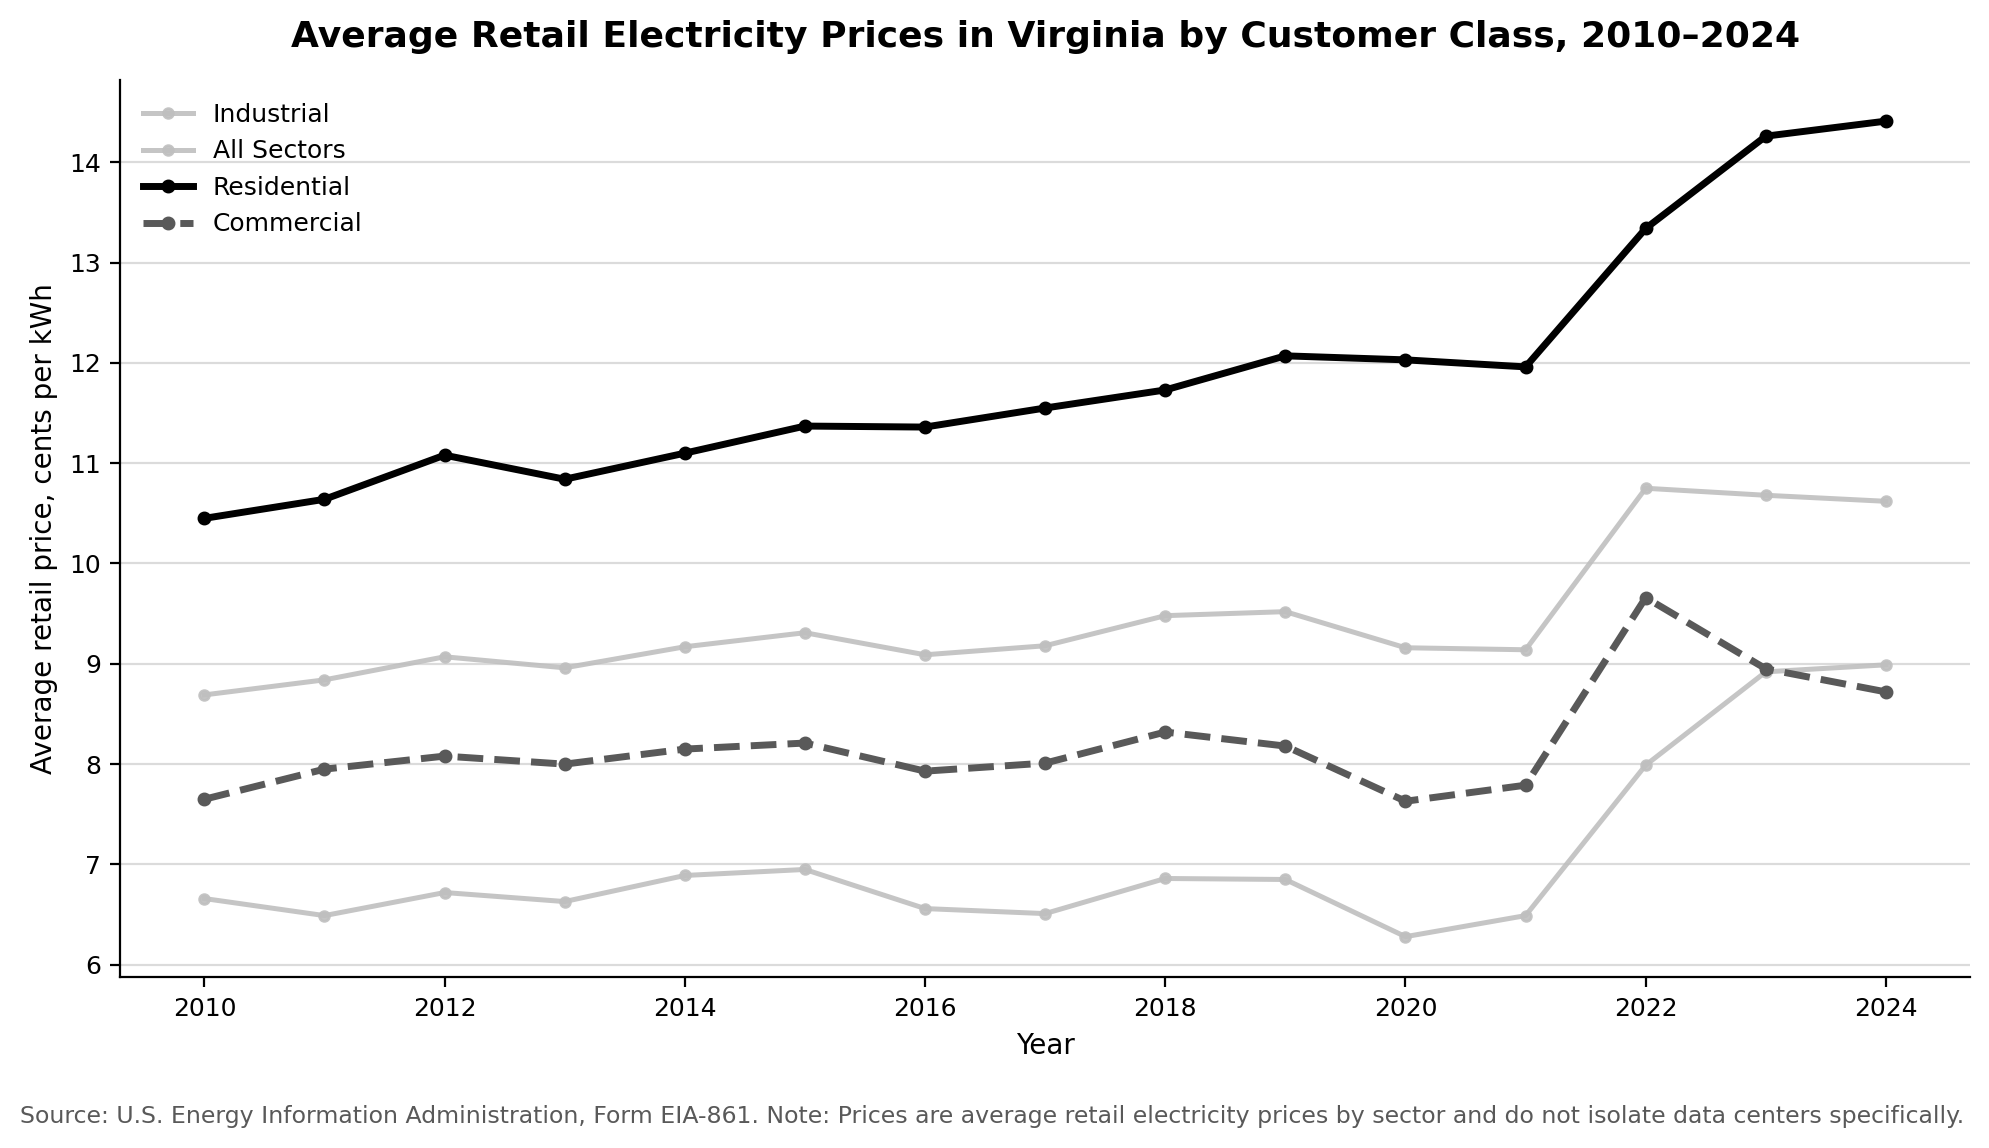

In [13]:
# Filter to Virginia
va = retail[retail["stateid"] == "VA"].copy()

fig, ax = plt.subplots(figsize=(10, 5.5), dpi=200)
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

# Plot muted comparison lines first
for sector in ["industrial", "all sectors"]:
    group = va[va["sectorName"] == sector].sort_values("period")
    ax.plot(
        group["period"],
        group["price"],
        marker="o",
        markersize=3.5,
        linewidth=1.8,
        color="0.75",
        alpha=0.9,
        label=sector.title()
    )

# Highlight residential
res = va[va["sectorName"] == "residential"].sort_values("period")
ax.plot(
    res["period"],
    res["price"],
    marker="o",
    markersize=4,
    linewidth=2.5,
    color="black",
    label="Residential"
)

# Highlight commercial
com = va[va["sectorName"] == "commercial"].sort_values("period")
ax.plot(
    com["period"],
    com["price"],
    marker="o",
    markersize=4,
    linewidth=2.5,
    linestyle="--",
    color="0.35",
    label="Commercial"
)

ax.set_title(
    "Average Retail Electricity Prices in Virginia by Customer Class, 2010–2024",
    fontsize=13,
    fontweight="bold",
    pad=12
)
ax.set_xlabel("Year", fontsize=10)
ax.set_ylabel("Average retail price, cents per kWh", fontsize=10)

ax.tick_params(axis="both", labelsize=9)
ax.grid(axis="y", color="0.86", linewidth=0.8)
ax.grid(axis="x", visible=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(frameon=False, fontsize=9, loc="upper left")

fig.text(
    0.01,
    -0.03,
    "Source: U.S. Energy Information Administration, Form EIA-861. "
    "Note: Prices are average retail electricity prices by sector and do not isolate data centers specifically.",
    ha="left",
    fontsize=8.5,
    color="0.35"
)

plt.tight_layout()
plt.show()

## Commercial Sales Growth Across States

This graph compares commercial electricity sales growth in Virginia with the other states in the dataset. Each state is indexed to its 2010 commercial sales level, so the figure shows relative growth over time rather than raw sales totals.

In [11]:
summary = []

for sector in ["COM", "IND", "ALL"]:
    g = va[va["sectorid"] == sector].sort_values("period")
    start_sales = g["sales"].iloc[0]
    end_sales = g["sales"].iloc[-1]
    growth_pct = (end_sales / start_sales - 1) * 100

    summary.append({
        "Sector": g["sectorName"].iloc[0].title(),
        "2010 Sales": start_sales,
        "2024 Sales": end_sales,
        "Growth %": growth_pct,
        "2024 Price": g["price"].iloc[-1],
        "2024 Customers": g["customers"].iloc[-1]
    })

summary_df = pd.DataFrame(summary)
summary_df

,Sector,2010 Sales,2024 Sales,Growth %,2024 Price,2024 Customers
0,Commercial,48036.98399,78710.66201,63.854296,8.72,445756.0
1,Industrial,17141.22400,13775.53000,-19.635086,8.99,3794.0
2,All Sectors,113806.13500,138044.77200,21.298181,10.62,4104032.0


## Summary Table

This table summarizes the main sector-level changes in Virginia from 2010 to 2024. It shows starting sales, ending sales, percent growth, 2024 average price, and the number of customers in 2024 for the commercial, industrial, and all-sector categories.

In [11]:
import statsmodels.api as sm

com = va[va["sectorid"]=="COM"].sort_values("period").copy()

com["time"] = range(len(com))
com["post2020"] = (com["period"] >= 2020).astype(int)
com["interaction"] = com["time"] * com["post2020"]

X = com[["time","post2020","interaction"]]
X = sm.add_constant(X)

model = sm.OLS(com["sales"],X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.988
Model:                            OLS   Adj. R-squared:                  0.984
Method:                 Least Squares   F-statistic:                     290.4
Date:                Sat, 25 Apr 2026   Prob (F-statistic):           9.45e-11
Time:                        21:21:32   Log-Likelihood:                -126.60
No. Observations:                  15   AIC:                             261.2
Df Residuals:                      11   BIC:                             264.0
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const        4.608e+04    768.783     59.934      

In [12]:
comparison = retail[
(retail["stateid"].isin(["MD","NC","PA"])) &
(retail["sectorid"]=="COM")
]

counter = comparison.groupby("period")["sales"].mean().reset_index()

va_com = retail[
(retail["stateid"]=="VA") &
(retail["sectorid"]=="COM")
]

In [13]:
com["pct_sales"] = com["sales"].pct_change()
com["pct_price"] = com["price"].pct_change()

elasticity = (
com["pct_sales"] /
com["pct_price"]
).mean()

print(elasticity)


0.0651561277412134
